# Big Data and Data Science

## From Clickstream Data to Purchase Prediction: A Practical Decision Tree Application

**Student:** Dave Dalcin  
**Student ID:** 93315  
**Course:** Big Data and Data Science  
**Institution:** Swiss School of Business and Management Geneva  
**Course Lecturer:** Sabrina Šuman, PhD, Senior Lecturer

# 1. Brief Description of the Practical Example

Online retail sessions do not all end in the same way. Most visitors leave without buying, while a smaller group completes a transaction. This practical example investigates whether information recorded during these sessions can help distinguish between the two outcomes.

The analysis uses the Online Shoppers Purchasing Intention Dataset from the UCI Machine Learning Repository. A Decision Tree is applied to classify sessions according to `Revenue`, which records whether a purchase occurred. Despite the name of the dataset, the target represents an observed transaction rather than the customer's psychological intention.

The practical work examines the preparation and understanding of the source data, the effect of class imbalance and the interpretation of the model's results. Overall accuracy is considered alongside measures that provide more information about purchasing sessions. A sensitivity analysis is also included to examine how strongly the findings depend on `PageValues`.

## 1.1 Tools and Development Environment

The analysis was developed in Visual Studio Code using a Jupyter Notebook and Python 3.14. The main libraries were pandas, NumPy, Matplotlib, Seaborn and scikit-learn, an open-source Python library for machine-learning applications (Pedregosa et al., 2011). GitHub Copilot with GPT-5.6 Sol Light was used as a coding assistant during development. Its suggestions were reviewed before use, while the execution, interpretation and validation of the results remained the responsibility of the author.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# 2. Source Data Preparation and Understanding

## 2.1 Dataset Background

The Online Shoppers Purchasing Intention Dataset was made available by Sakar and Kastro (2018) through the UCI Machine Learning Repository. The dataset is associated with research on the real-time prediction of online purchasing behaviour using aggregated session information (Sakar et al., 2019).

It contains 12,330 sessions collected over a one-year period. According to the dataset documentation, the records were organised so that each session belonged to a different user, reducing the likelihood that the observations would be dominated by a particular customer, campaign or period.

Each row represents one session through 17 predictor variables and the target `Revenue`. The predictors combine page activity, time spent on different page categories, web analytics measures and contextual information such as month, visitor type and weekend access. `Revenue` is `True` when the session ended with a transaction and `False` otherwise.

The dataset supports a transparent classification example, but it should not be treated as a complete representation of a contemporary e-commerce Big Data environment. It contains aggregated session records rather than a continuous stream of raw click events, customer histories or interactions across multiple channels.

The variables can be organised into the following groups:

| Group | Variables | Role in the analysis |
|---|---|---|
| Page activity | `Administrative`, `Informational`, `ProductRelated` and their duration variables | Describe the number of pages visited and the time spent on each page category |
| Web analytics | `BounceRates`, `ExitRates`, `PageValues` | Represent measures associated with engagement, exits and page contribution to transactions |
| Temporal context | `SpecialDay`, `Month`, `Weekend` | Describe when the session occurred |
| Technical and traffic context | `OperatingSystems`, `Browser`, `Region`, `TrafficType` | Represent the technical or acquisition context of the session |
| Visitor context | `VisitorType` | Distinguishes returning, new and other visitor types |
| Target | `Revenue` | Indicates whether the session ended with a transaction |

## 2.2 Data Loading

The source CSV file is loaded without changing its original content. Its dimensions are checked immediately to confirm that the expected number of sessions and columns is present.

In [2]:
data_path = Path("../data/online_shoppers_intention.csv").resolve()

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path}")

df_raw = pd.read_csv(data_path)

print(f"Dataset file: {data_path.name}")
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")

Dataset file: online_shoppers_intention.csv
Rows: 12,330
Columns: 18


In [3]:
df_raw.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2.3 Dataset Structure and Variable Types

The initial inspection checks how pandas interpreted each column and whether values are missing. Particular care is required because some variables stored as integers, including operating system, browser, region and traffic type, represent category codes rather than continuous quantities.

In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [5]:
variable_summary = pd.DataFrame({
    "Data type": df_raw.dtypes.astype(str),
    "Non-null values": df_raw.notna().sum(),
    "Missing values": df_raw.isna().sum(),
    "Unique values": df_raw.nunique()
})

variable_summary

,Data type,Non-null values,Missing values,Unique values
Administrative,int64,12330,0,27
Administrative_Duration,float64,12330,0,3335
Informational,int64,12330,0,17
Informational_Duration,float64,12330,0,1258
ProductRelated,int64,12330,0,311
ProductRelated_Duration,float64,12330,0,9551
BounceRates,float64,12330,0,1872
ExitRates,float64,12330,0,4777
PageValues,float64,12330,0,2704
SpecialDay,float64,12330,0,6


The inspection found no missing values in any of the 18 columns. Page counts were read as integers, while duration and web analytics measures were read as floating-point values. `Month` and `VisitorType` were recognised as text, whereas `Weekend` and the target `Revenue` were read as Boolean variables.

The data type alone does not determine how a variable should be treated. `OperatingSystems`, `Browser`, `Region` and `TrafficType` contain numerical codes, but the values identify categories rather than measurable quantities. Treating a browser code as larger or smaller than another browser code would have no meaningful interpretation. These variables will therefore be handled as categorical features during model preparation.

## 2.4 Target Variable and Class Distribution

`Revenue` is the outcome to be predicted. Before the model is developed, its distribution needs to be examined because a large difference between the two classes can make overall accuracy misleading.

In [6]:
target_distribution = (
    df_raw["Revenue"]
    .value_counts()
    .reindex([False, True])
    .rename_axis("Revenue")
    .reset_index(name="Sessions")
)

target_distribution["Outcome"] = target_distribution["Revenue"].map({
    False: "No purchase",
    True: "Purchase"
})

target_distribution["Percentage"] = (
    target_distribution["Sessions"] / len(df_raw) * 100
).round(2)

target_distribution[["Outcome", "Sessions", "Percentage"]]

,Outcome,Sessions,Percentage
0,No purchase,10422,84.53
1,Purchase,1908,15.47


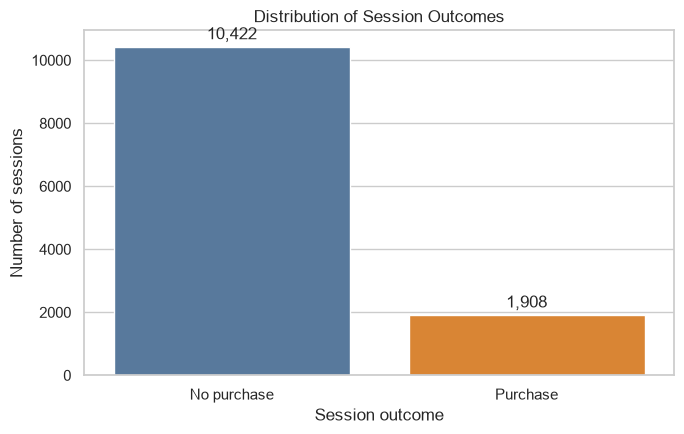

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.countplot(
    data=df_raw,
    x="Revenue",
    order=[False, True],
    hue="Revenue",
    palette={False: "#4C78A8", True: "#F58518"},
    legend=False,
    ax=ax
)

ax.set_title("Distribution of Session Outcomes")
ax.set_xlabel("Session outcome")
ax.set_ylabel("Number of sessions")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No purchase", "Purchase"])

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)

plt.tight_layout()

output_path = Path("../outputs").resolve()
output_path.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_path / "revenue_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Purchasing sessions account for 1,908 observations, or 15.47% of the dataset. The remaining 10,422 sessions did not end with a transaction. This means that a classifier could predict “No purchase” for every session and still achieve an accuracy of 84.53%.

Such a result would have little practical value because none of the purchasing sessions would be identified. Overall accuracy will therefore be reported, but it cannot be treated as sufficient evidence of model quality. Precision, recall, F1-score, balanced accuracy and the confusion matrix will be used to examine how the model performs on both classes.

## 2.5 Missing Values and Exact Duplicate Rows

Missing values and exact duplicate rows are examined before any preparation decision is made. Exact matches require particular care because the dataset does not contain a session identifier. Two rows with the same aggregated values may represent duplicated records, but they may also describe separate sessions that happened to produce the same measurements.

In [8]:
missing_values = int(df_raw.isna().sum().sum())
additional_duplicate_rows = int(df_raw.duplicated().sum())
all_rows_in_duplicate_groups = int(
    df_raw.duplicated(keep=False).sum()
)

data_quality_summary = pd.DataFrame({
    "Check": [
        "Missing values",
        "Additional exact duplicate rows",
        "All rows involved in duplicate groups"
    ],
    "Result": [
        missing_values,
        additional_duplicate_rows,
        all_rows_in_duplicate_groups
    ]
})

data_quality_summary

,Check,Result
0,Missing values,0
1,Additional exact duplicate rows,125
2,All rows involved in duplicate groups,201


In [9]:
duplicate_group_rows = df_raw[
    df_raw.duplicated(keep=False)
].copy()

duplicate_target_summary = (
    duplicate_group_rows["Revenue"]
    .value_counts()
    .reindex([False, True], fill_value=0)
    .rename(index={False: "No purchase", True: "Purchase"})
    .rename_axis("Outcome")
    .reset_index(name="Rows in duplicate groups")
)

duplicate_target_summary

,Outcome,Rows in duplicate groups
0,No purchase,201
1,Purchase,0


No missing values were found. The duplicate check identified 125 additional exact matches, with 201 rows involved in duplicate groups. All of these observations belong to the “No purchase” class.

The matching rows were retained. The dataset documentation states that each record represents a different user session, while the file contains no session identifier that would allow accidental duplication to be confirmed. Since the features are aggregated, separate sessions may legitimately produce the same recorded values. Removing the matches would also affect only the majority class and alter the observed purchase prevalence without clear evidence that the records are invalid. The absence of a session identifier remains a limitation of this decision.

## 2.6 Numerical Data Summary

Summary statistics are used to examine the scale and distribution of the behavioural measures. Numerical category codes are excluded because calculating averages for browser, region or operating system identifiers would not have a meaningful interpretation.

In [10]:
numerical_measure_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

numerical_summary = (
    df_raw[numerical_measure_columns]
    .describe()
    .T
    .round(3)
)

numerical_summary

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315,3.322,0.0,0.000,1.000,4.000,27.000
Administrative_Duration,12330.0,80.819,176.779,0.0,0.000,7.500,93.256,3398.750
Informational,12330.0,0.504,1.270,0.0,0.000,0.000,0.000,24.000
Informational_Duration,12330.0,34.472,140.749,0.0,0.000,0.000,0.000,2549.375
ProductRelated,12330.0,31.731,44.476,0.0,7.000,18.000,38.000,705.000
ProductRelated_Duration,12330.0,1194.746,1913.669,0.0,184.138,598.937,1464.157,63973.522
BounceRates,12330.0,0.022,0.048,0.0,0.000,0.003,0.017,0.200
ExitRates,12330.0,0.043,0.049,0.0,0.014,0.025,0.050,0.200
PageValues,12330.0,5.889,18.568,0.0,0.000,0.000,0.000,361.764
SpecialDay,12330.0,0.061,0.199,0.0,0.000,0.000,0.000,1.000


In [11]:
numerical_summary_extended = pd.DataFrame({
    "Minimum": df_raw[numerical_measure_columns].min(),
    "Median": df_raw[numerical_measure_columns].median(),
    "Mean": df_raw[numerical_measure_columns].mean(),
    "Maximum": df_raw[numerical_measure_columns].max(),
    "Zero values": (df_raw[numerical_measure_columns] == 0).sum()
}).round(3)

numerical_summary_extended

,Minimum,Median,Mean,Maximum,Zero values
Administrative,0.0,1.000,2.315,27.000,5768
Administrative_Duration,0.0,7.500,80.819,3398.750,5903
Informational,0.0,0.000,0.504,24.000,9699
Informational_Duration,0.0,0.000,34.472,2549.375,9925
ProductRelated,0.0,18.000,31.731,705.000,38
ProductRelated_Duration,0.0,598.937,1194.746,63973.522,755
BounceRates,0.0,0.003,0.022,0.200,5518
ExitRates,0.0,0.025,0.043,0.200,76
PageValues,0.0,0.000,5.889,361.764,9600
SpecialDay,0.0,0.000,0.061,1.000,11079


The behavioural measures are generally right-skewed. Most sessions contain limited activity, while a smaller number include substantially more page views or longer durations. This is particularly visible in the difference between the mean and median values. For example, the median product-related duration is 598.937, compared with a mean of 1,194.746 and a maximum above 63,000.

Zero values are common but do not necessarily indicate missing data. A value of zero can mean that a visitor did not access a particular page category during the session. Informational pages were not visited in 9,699 sessions, while `PageValues` was zero in 9,600 sessions. `SpecialDay` was zero for most observations because only sessions occurring close to a relevant commercial date receive a non-zero value.

The highest values deserve attention, but they were not removed solely because they are far from the median. Long sessions and extensive browsing may represent genuine customer behaviour. Decision Trees also do not require variables to be standardised and can divide observations through thresholds. The original numerical values are therefore retained unless a later check identifies an invalid measurement. `PageValues` will be examined separately because its calculation may affect whether it would be available at the intended prediction point.

## 2.7 Categorical and Context Variable Inspection

The categorical and context variables are inspected to confirm their observed values before encoding. Some are stored as text or Boolean values, while others use integer codes. The codes are treated as labels and not as quantities.

In [12]:
categorical_columns = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

category_orders = {
    "Month": [
        "Feb", "Mar", "May", "June", "Jul",
        "Aug", "Sep", "Oct", "Nov", "Dec"
    ],
    "VisitorType": [
        "Returning_Visitor", "New_Visitor", "Other"
    ],
    "Weekend": [
        False, True
    ]
}

def format_observed_values(column):
    observed = df_raw[column].dropna().unique().tolist()

    if column in category_orders:
        ordered = [
            value for value in category_orders[column]
            if value in observed
        ]
    else:
        ordered = sorted(observed)

    return ", ".join(map(str, ordered))

categorical_value_summary = pd.DataFrame({
    "Variable": categorical_columns,
    "Unique values": [
        df_raw[column].nunique()
        for column in categorical_columns
    ],
    "Observed values": [
        format_observed_values(column)
        for column in categorical_columns
    ]
})

categorical_value_summary.style \
    .hide(axis="index") \
    .set_properties(
        subset=["Variable", "Observed values"],
        **{"text-align": "left"}
    ) \
    .set_properties(
        subset=["Unique values"],
        **{"text-align": "center"}
    ) \
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("white-space", "normal"),
                ("max-width", "550px")
            ]
        }
    ])

Variable,Unique values,Observed values
Month,10,"Feb, Mar, May, June, Jul, Aug, Sep, Oct, Nov, Dec"
OperatingSystems,8,"1, 2, 3, 4, 5, 6, 7, 8"
Browser,13,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13"
Region,9,"1, 2, 3, 4, 5, 6, 7, 8, 9"
TrafficType,20,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20"
VisitorType,3,"Returning_Visitor, New_Visitor, Other"
Weekend,2,"False, True"


In [13]:
month_order = [
    "Feb", "Mar", "May", "June", "Jul",
    "Aug", "Sep", "Oct", "Nov", "Dec"
]

month_distribution = (
    df_raw["Month"]
    .value_counts()
    .reindex(month_order)
    .rename_axis("Month")
    .reset_index(name="Sessions")
)

visitor_distribution = (
    df_raw["VisitorType"]
    .value_counts()
    .rename_axis("Visitor type")
    .reset_index(name="Sessions")
)

display(month_distribution)
display(visitor_distribution)

,Month,Sessions
0,Feb,184
1,Mar,1907
2,May,3364
3,June,288
4,Jul,432
5,Aug,433
6,Sep,448
7,Oct,549
8,Nov,2998
9,Dec,1727


,Visitor type,Sessions
0,Returning_Visitor,10551
1,New_Visitor,1694
2,Other,85


The observed categories are internally consistent. The dataset contains sessions from ten months, with no records for January or April. This absence is a characteristic of the source data and was not treated as missing information. May and November contain the largest numbers of sessions.

Returning visitors account for most observations, with 10,551 sessions, compared with 1,694 new visitors and 85 observations classified as `Other`. The technical and traffic variables contain integer codes within their documented ranges. Their original labels are unavailable, so they can distinguish categories but cannot support conclusions about a particular browser, region or traffic source.

No category was removed or renamed. During preprocessing, `Month`, `VisitorType`, `Weekend`, `OperatingSystems`, `Browser`, `Region` and `TrafficType` will be encoded as categorical predictors.

## 2.8 Preliminary Relationships with Revenue

A descriptive comparison is made before modelling to identify differences between purchasing and non-purchasing sessions. Because several numerical variables are strongly skewed, medians are used instead of means for this initial comparison. These relationships are descriptive and should not be interpreted as evidence that a feature causes a purchase.

In [14]:
comparison_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

median_by_outcome = (
    df_raw
    .groupby("Revenue")[comparison_columns]
    .median()
    .T
    .rename(columns={
        False: "No purchase",
        True: "Purchase"
    })
    .round(3)
)

median_by_outcome

Revenue,No purchase,Purchase
Administrative,0.000,2.000
Administrative_Duration,0.000,52.367
Informational,0.000,0.000
Informational_Duration,0.000,0.000
ProductRelated,16.000,29.000
ProductRelated_Duration,510.190,1109.906
BounceRates,0.004,0.000
ExitRates,0.029,0.016
PageValues,0.000,16.758


In [15]:
purchase_rate_by_visitor = (
    df_raw
    .groupby("VisitorType", observed=True)
    .agg(
        Sessions=("Revenue", "size"),
        Purchases=("Revenue", "sum"),
        Purchase_rate=("Revenue", "mean")
    )
    .sort_values("Sessions", ascending=False)
)

purchase_rate_by_visitor["Purchase_rate"] = (
    purchase_rate_by_visitor["Purchase_rate"] * 100
).round(2)

purchase_rate_by_visitor

,Sessions,Purchases,Purchase_rate
VisitorType,,,
Returning_Visitor,10551,1470,13.93
New_Visitor,1694,422,24.91
Other,85,16,18.82


In [16]:
purchase_rate_by_month = (
    df_raw
    .groupby("Month", observed=True)
    .agg(
        Sessions=("Revenue", "size"),
        Purchases=("Revenue", "sum"),
        Purchase_rate=("Revenue", "mean")
    )
    .reindex(month_order)
)

purchase_rate_by_month["Purchase_rate"] = (
    purchase_rate_by_month["Purchase_rate"] * 100
).round(2)

purchase_rate_by_month

,Sessions,Purchases,Purchase_rate
Month,,,
Feb,184,3,1.63
Mar,1907,192,10.07
May,3364,365,10.85
June,288,29,10.07
Jul,432,66,15.28
Aug,433,76,17.55
Sep,448,86,19.20
Oct,549,115,20.95
Nov,2998,760,25.35


Purchasing sessions show stronger engagement with product-related content. Their median number of product-related pages is 29, compared with 16 for sessions without a purchase. Median time spent on these pages is also more than twice as high. Purchasing sessions have lower median bounce and exit rates, which is consistent with visitors progressing further through the website.

The clearest difference appears in `PageValues`. Its median is zero for sessions without a purchase and 16.758 for purchasing sessions. This strong relationship may make the variable useful for classification, but it also raises a timing question. Its operational value depends on whether it could be calculated before the intended prediction point. The main model will include it, followed by a sensitivity analysis in which it is excluded.

New visitors recorded a purchase rate of 24.91%, compared with 13.93% among returning visitors. This does not mean that being a new visitor caused the transaction, since the groups may differ in purpose, source or browsing behaviour. The `Other` category contains only 85 sessions, so its rate is based on a relatively small sample.

Purchase rates also vary across months. February has the lowest rate at 1.63%, although it contains only 184 sessions. The rate increases from July and reaches 25.35% in November before falling to 12.51% in December. These differences may reflect seasonality, campaigns or changes in the composition of website traffic. They are descriptive patterns and should not be interpreted as isolated month effects.

## 2.9 Data Understanding Summary

The inspection confirmed that the dataset is suitable for a classification example. It contains the expected 12,330 sessions and has no missing values. Exact matches were retained because the aggregated records do not provide enough evidence to identify them as erroneous duplicates. Numerical measures are strongly skewed, but extreme values were not removed without evidence that they were invalid.

The target is imbalanced, with purchases representing 15.47% of the sessions. This makes the majority-class accuracy of 84.53% an important baseline for later evaluation. Numerical category codes will be encoded as categorical features, and the original numerical measures will be retained without standardisation. The relationship between `PageValues` and `Revenue` will be addressed through a separate sensitivity analysis.

# 3. Data Preparation

## 3.1 Predictor and Target Definition

The dataset is divided into predictors and the binary target before model development. `Revenue` is converted to an integer in which 1 represents a purchasing session and 0 represents a session without a purchase. The predictors are then separated into numerical measures and categorical features according to their meaning rather than their storage type.

In [17]:
df_model = df_raw.copy()

X = df_model.drop(columns="Revenue")
y = df_model["Revenue"].astype(int)

categorical_features = categorical_columns.copy()

numerical_features = [
    column for column in X.columns
    if column not in categorical_features
]

feature_role_summary = pd.DataFrame({
    "Feature group": ["Numerical measures", "Categorical features", "Target"],
    "Number of variables": [
        len(numerical_features),
        len(categorical_features),
        1
    ],
    "Variables": [
        ", ".join(numerical_features),
        ", ".join(categorical_features),
        "Revenue"
    ]
})

feature_role_summary.style \
    .hide(axis="index") \
    .set_properties(
        subset=["Feature group", "Variables"],
        **{"text-align": "left"}
    ) \
    .set_properties(
        subset=["Number of variables"],
        **{"text-align": "center"}
    )

Feature group,Number of variables,Variables
Numerical measures,10,"Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues, SpecialDay"
Categorical features,7,"Month, OperatingSystems, Browser, Region, TrafficType, VisitorType, Weekend"
Target,1,Revenue


In [18]:
model_data_summary = pd.DataFrame({
    "Item": [
        "Predictor matrix",
        "Target vector",
        "Target encoding"
    ],
    "Result": [
        f"{X.shape[0]:,} sessions × {X.shape[1]} predictors",
        f"{y.shape[0]:,} observations",
        "0 = No purchase; 1 = Purchase"
    ]
})

model_data_summary.style \
    .hide(axis="index") \
    .set_properties(
        subset=["Item", "Result"],
        **{"text-align": "left"}
    ) \
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("font-weight", "bold")
            ]
        }
    ])

Item,Result
Predictor matrix,"12,330 sessions × 17 predictors"
Target vector,"12,330 observations"
Target encoding,0 = No purchase; 1 = Purchase


The modelling dataset contains 17 predictors: ten numerical measures and seven categorical features. The binary target contains the same 12,330 observations, with 1 representing a purchase and 0 representing no purchase.

## 3.2 Stratified Train-Test Split

The data are divided into training and test sets before any preprocessing is fitted. The training set is used to develop the model, while the test set is kept separate for the final evaluation. An 80:20 split is applied with stratification so that the purchase rate remains similar in both sets. A fixed random state makes the split reproducible.


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

In [21]:
split_summary = pd.DataFrame({
    "Dataset": ["Training set", "Test set"],
    "Sessions": [
        len(y_train),
        len(y_test)
    ],
    "No purchase": [
        int((y_train == 0).sum()),
        int((y_test == 0).sum())
    ],
    "Purchase": [
        int((y_train == 1).sum()),
        int((y_test == 1).sum())
    ],
    "Purchase rate (%)": [
        round(y_train.mean() * 100, 2),
        round(y_test.mean() * 100, 2)
    ]
})

split_summary.style \
    .hide(axis="index") \
    .format({
        "Sessions": "{:,}",
        "No purchase": "{:,}",
        "Purchase": "{:,}",
        "Purchase rate (%)": "{:.2f}"
    }) \
    .set_properties(
        subset=["Dataset"],
        **{"text-align": "left"}
    ) \
    .set_properties(
        subset=[
            "Sessions",
            "No purchase",
            "Purchase",
            "Purchase rate (%)"
        ],
        **{"text-align": "center"}
    )

Dataset,Sessions,No purchase,Purchase,Purchase rate (%)
Training set,"9,864","8,338","1,526",15.47
Test set,"2,466","2,084",382,15.49


The stratified split preserved the original class distribution. The training set contains 9,864 sessions and will be used for model development. The test set contains 2,466 sessions and remains separate until evaluation. This reduces the risk of estimating performance on information already used to fit the model.

# 4. Model Development and Evaluation

## 4.1 Majority-Class Baseline

A majority-class baseline is calculated before training the Decision Tree. It predicts “No purchase” for every session. This provides a minimum reference for evaluating whether the trained model identifies purchasing sessions rather than achieving a high accuracy by following the dominant class.

In [22]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

In [23]:
baseline_predictions = np.zeros(len(y_test), dtype=int)

baseline_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Precision — Purchase",
        "Recall — Purchase",
        "F1-score — Purchase"
    ],
    "Score": [
        accuracy_score(y_test, baseline_predictions),
        balanced_accuracy_score(y_test, baseline_predictions),
        precision_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            baseline_predictions,
            zero_division=0
        )
    ]
})

baseline_metrics.style \
    .hide(axis="index") \
    .format({"Score": "{:.3f}"}) \
    .set_properties(
        subset=["Metric"],
        **{"text-align": "left"}
    ) \
    .set_properties(
        subset=["Score"],
        **{"text-align": "center"}
    )

Metric,Score
Accuracy,0.845
Balanced accuracy,0.500
Precision — Purchase,0.000
Recall — Purchase,0.000
F1-score — Purchase,0.000


The baseline achieves an accuracy of 0.845 because most sessions do not end in a purchase. However, its precision, recall and F1-score for the purchase class are all zero. It fails to identify every one of the 382 purchasing sessions in the test set.

Balanced accuracy falls to 0.500 because the baseline recognises only one of the two classes. This demonstrates why overall accuracy cannot be used alone for this dataset. The Decision Tree must improve the identification of purchasing sessions while maintaining an acceptable error rate for sessions without a purchase.

## 4.2 Preprocessing Pipeline

The categorical predictors require encoding before they can be used by scikit-learn. One-hot encoding creates a separate binary indicator for each observed category and avoids treating category codes as ordered quantities. Unknown categories are ignored so that the pipeline can process a test observation even if its category was not present during training.

The numerical measures are passed to the model without scaling. Decision Trees divide variables through thresholds and do not depend on the distance between standardised values. No missing-value treatment is required because the initial inspection found complete data. The preprocessing stage will be fitted only through the training pipeline.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [26]:
preprocessing_summary = pd.DataFrame({
    "Feature group": [
        "Categorical features",
        "Numerical measures"
    ],
    "Number of features": [
        len(categorical_features),
        len(numerical_features)
    ],
    "Treatment": [
        "One-hot encoding",
        "No transformation"
    ],
    "Reason": [
        "Category labels should not be interpreted as ordered quantities.",
        "Decision Trees do not require feature scaling."
    ]
})

preprocessing_summary.style \
    .hide(axis="index") \
    .set_properties(
        subset=["Feature group", "Treatment", "Reason"],
        **{
            "text-align": "left",
            "white-space": "normal"
        }
    ) \
    .set_properties(
        subset=["Number of features"],
        **{"text-align": "center"}
    ) \
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px 10px")
            ]
        }
    ])

Feature group,Number of features,Treatment,Reason
Categorical features,7,One-hot encoding,Category labels should not be interpreted as ordered quantities.
Numerical measures,10,No transformation,Decision Trees do not require feature scaling.


## 4.3 Decision Tree Method

A Decision Tree classifies observations through a sequence of rules. At each node, the algorithm selects a feature and threshold that divide the data into increasingly homogeneous groups. The final leaves assign a predicted class. This structure makes the method easier to inspect than many more complex classifiers, although an unrestricted tree may fit noise and become difficult to interpret.

The model parameters are selected through five-fold stratified cross-validation using only the training set. Balanced accuracy is used as the selection measure because it gives equal importance to performance on purchasing and non-purchasing sessions. The search considers tree depth, minimum leaf size, split criterion and class weighting. The separate test set is not used during this process.

In [27]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

In [28]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [29]:
parameter_grid = {
    "classifier__criterion": [
        "gini",
        "entropy"
    ],
    "classifier__max_depth": [
        3, 4, 5, 6, 7, None
    ],
    "classifier__min_samples_leaf": [
        10, 20, 50, 100
    ],
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [30]:
number_of_candidates = int(
    np.prod([
        len(values)
        for values in parameter_grid.values()
    ])
)

search_configuration = pd.DataFrame({
    "Setting": [
        "Method",
        "Selection metric",
        "Cross-validation",
        "Parameter combinations",
        "Training observations",
        "Test set used during selection"
    ],
    "Value": [
        "Decision Tree",
        "Balanced accuracy",
        "5-fold stratified",
        f"{number_of_candidates}",
        f"{len(y_train):,}",
        "No"
    ]
})

search_configuration.style \
    .hide(axis="index") \
    .set_properties(
        subset=["Setting", "Value"],
        **{"text-align": "left"}
    )

Setting,Value
Method,Decision Tree
Selection metric,Balanced accuracy
Cross-validation,5-fold stratified
Parameter combinations,96
Training observations,"9,864"
Test set used during selection,No


In [31]:
grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=parameter_grid,
    scoring="balanced_accuracy",
    cv=cross_validation,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

_ = grid_search.fit(X_train, y_train)

In [32]:
best_parameters = pd.DataFrame({
    "Parameter": [
        "Split criterion",
        "Maximum depth",
        "Minimum samples per leaf",
        "Class weighting",
        "Mean cross-validation balanced accuracy"
    ],
    "Selected value": [
        grid_search.best_params_["classifier__criterion"],
        grid_search.best_params_["classifier__max_depth"],
        grid_search.best_params_["classifier__min_samples_leaf"],
        grid_search.best_params_["classifier__class_weight"],
        f"{grid_search.best_score_:.3f}"
    ]
})

best_parameters.style \
    .hide(axis="index") \
    .set_properties(
        subset=["Parameter", "Selected value"],
        **{"text-align": "left"}
    )

Parameter,Selected value
Split criterion,gini
Maximum depth,3
Minimum samples per leaf,100
Class weighting,balanced
Mean cross-validation balanced accuracy,0.855


One-hot encoding converted the categorical predictors into binary indicators, while the ten numerical measures remained unchanged. These indicators are alternative representations of the original predictors rather than additional variables collected from the sessions.

Cross-validation selected the Gini split criterion. Gini impurity measures how mixed the purchase and non-purchase classes are within a node. The tree selects divisions that reduce this mixture and produce more homogeneous branches.

## 4.4 Test-Set Performance

The selected Decision Tree is now evaluated on the test set that was kept outside model development. Its results are compared with the majority-class baseline. The comparison includes overall accuracy and measures focused on the purchase class.

In [33]:
best_model = grid_search.best_estimator_

test_predictions = best_model.predict(X_test)
test_probabilities = best_model.predict_proba(X_test)[:, 1]

In [34]:
decision_tree_scores = [
    accuracy_score(y_test, test_predictions),
    balanced_accuracy_score(y_test, test_predictions),
    precision_score(y_test, test_predictions),
    recall_score(y_test, test_predictions),
    f1_score(y_test, test_predictions)
]

model_comparison = baseline_metrics.copy()
model_comparison = model_comparison.rename(
    columns={"Score": "Baseline"}
)

model_comparison["Decision Tree"] = decision_tree_scores
model_comparison["Difference"] = (
    model_comparison["Decision Tree"]
    - model_comparison["Baseline"]
)

model_comparison.style \
    .hide(axis="index") \
    .format({
        "Baseline": "{:.3f}",
        "Decision Tree": "{:.3f}",
        "Difference": "{:+.3f}"
    }) \
    .set_properties(
        subset=["Metric"],
        **{"text-align": "left"}
    ) \
    .set_properties(
        subset=["Baseline", "Decision Tree", "Difference"],
        **{"text-align": "center"}
    )

Metric,Baseline,Decision Tree,Difference
Accuracy,0.845,0.833,-0.013
Balanced accuracy,0.500,0.843,+0.343
Precision — Purchase,0.000,0.477,+0.477
Recall — Purchase,0.000,0.859,+0.859
F1-score — Purchase,0.000,0.614,+0.614


## 4.5 Confusion Matrix

The confusion matrix separates correct predictions from the two types of classification error. A false positive is a session predicted as a purchase that did not result in revenue. A false negative is an actual purchasing session that the model failed to identify.

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [36]:
test_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions
)

true_negative, false_positive, false_negative, true_positive = (
    test_confusion_matrix.ravel()
)

In [37]:
confusion_table = pd.DataFrame({
    "Actual outcome": [
        "No purchase",
        "Purchase"
    ],
    "Predicted: No purchase": [
        true_negative,
        false_negative
    ],
    "Predicted: Purchase": [
        false_positive,
        true_positive
    ]
})

confusion_table.style \
    .hide(axis="index") \
    .format({
        "Predicted: No purchase": "{:,}",
        "Predicted: Purchase": "{:,}"
    }) \
    .set_properties(
        subset=["Actual outcome"],
        **{"text-align": "left"}
    ) \
    .set_properties(
        subset=[
            "Predicted: No purchase",
            "Predicted: Purchase"
        ],
        **{"text-align": "center"}
    )

Actual outcome,Predicted: No purchase,Predicted: Purchase
No purchase,"1,725",359
Purchase,54,328


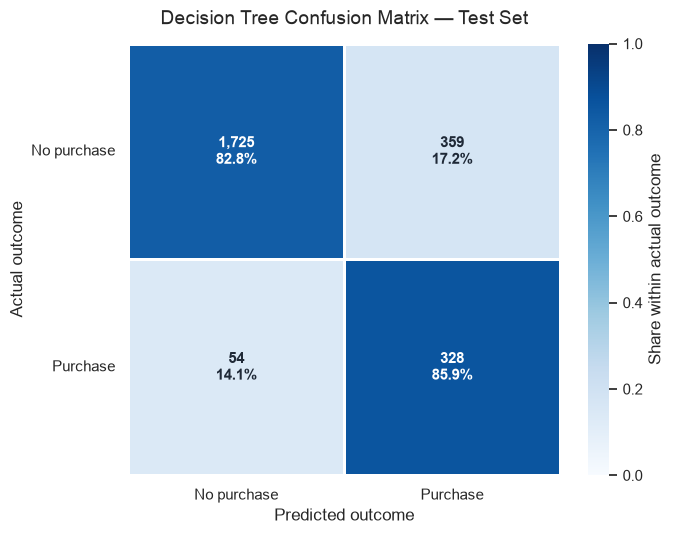

In [38]:
row_percentages = (
    test_confusion_matrix
    / test_confusion_matrix.sum(axis=1, keepdims=True)
)

annotations = np.empty_like(
    test_confusion_matrix,
    dtype=object
)

for row in range(test_confusion_matrix.shape[0]):
    for column in range(test_confusion_matrix.shape[1]):
        count = test_confusion_matrix[row, column]
        percentage = row_percentages[row, column]

        annotations[row, column] = (
            f"{count:,}\n{percentage:.1%}"
        )

fig, ax = plt.subplots(figsize=(7, 5.5))

sns.heatmap(
    row_percentages,
    annot=annotations,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Share within actual outcome"
    },
    ax=ax
)

ax.set_title(
    "Decision Tree Confusion Matrix — Test Set",
    fontsize=14,
    pad=14
)

ax.set_xlabel("Predicted outcome")
ax.set_ylabel("Actual outcome")

ax.set_xticklabels(
    ["No purchase", "Purchase"],
    rotation=0
)

ax.set_yticklabels(
    ["No purchase", "Purchase"],
    rotation=0
)

for text, percentage in zip(
    ax.texts,
    row_percentages.flatten()
):
    text.set_color(
        "white" if percentage >= 0.50 else "#1f2937"
    )
    text.set_fontsize(11)
    text.set_fontweight("bold")

plt.tight_layout()

fig.savefig(
    output_path / "decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.6 Decision Tree Structure

The selected tree has a maximum depth of three, allowing its complete decision structure to be inspected. Each node shows the rule used to divide the sessions, the proportion of training observations reaching that node and the predicted outcome. The Gini values reflect the balanced class weights used during training rather than the original class prevalence.

In [39]:
from sklearn.tree import plot_tree

In [40]:
# Extract the fitted preprocessing and classification components

fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_tree = best_model.named_steps["classifier"]

transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

feature_importance_results = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": fitted_tree.feature_importances_
})

used_features = (
    feature_importance_results
    .query("Importance > 0")
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

model_structure_summary = pd.DataFrame({
    "Item": [
        "Original predictors",
        "Predictors after preprocessing",
        "Predictors used by the selected tree",
        "Tree depth",
        "Terminal leaves"
    ],
    "Result": [
        f"{X_train.shape[1]}",
        f"{len(transformed_feature_names)}",
        f"{len(used_features)}",
        f"{fitted_tree.get_depth()}",
        f"{fitted_tree.get_n_leaves()}"
    ]
})

model_structure_summary.style \
    .hide(axis="index") \
    .set_caption("Selected Decision Tree Structure") \
    .set_properties(
        subset=["Item"],
        **{"text-align": "left", "min-width": "240px"}
    ) \
    .set_properties(
        subset=["Result"],
        **{"text-align": "center", "width": "120px"}
    )

Item,Result
Original predictors,17
Predictors after preprocessing,75
Predictors used by the selected tree,6
Tree depth,3
Terminal leaves,8


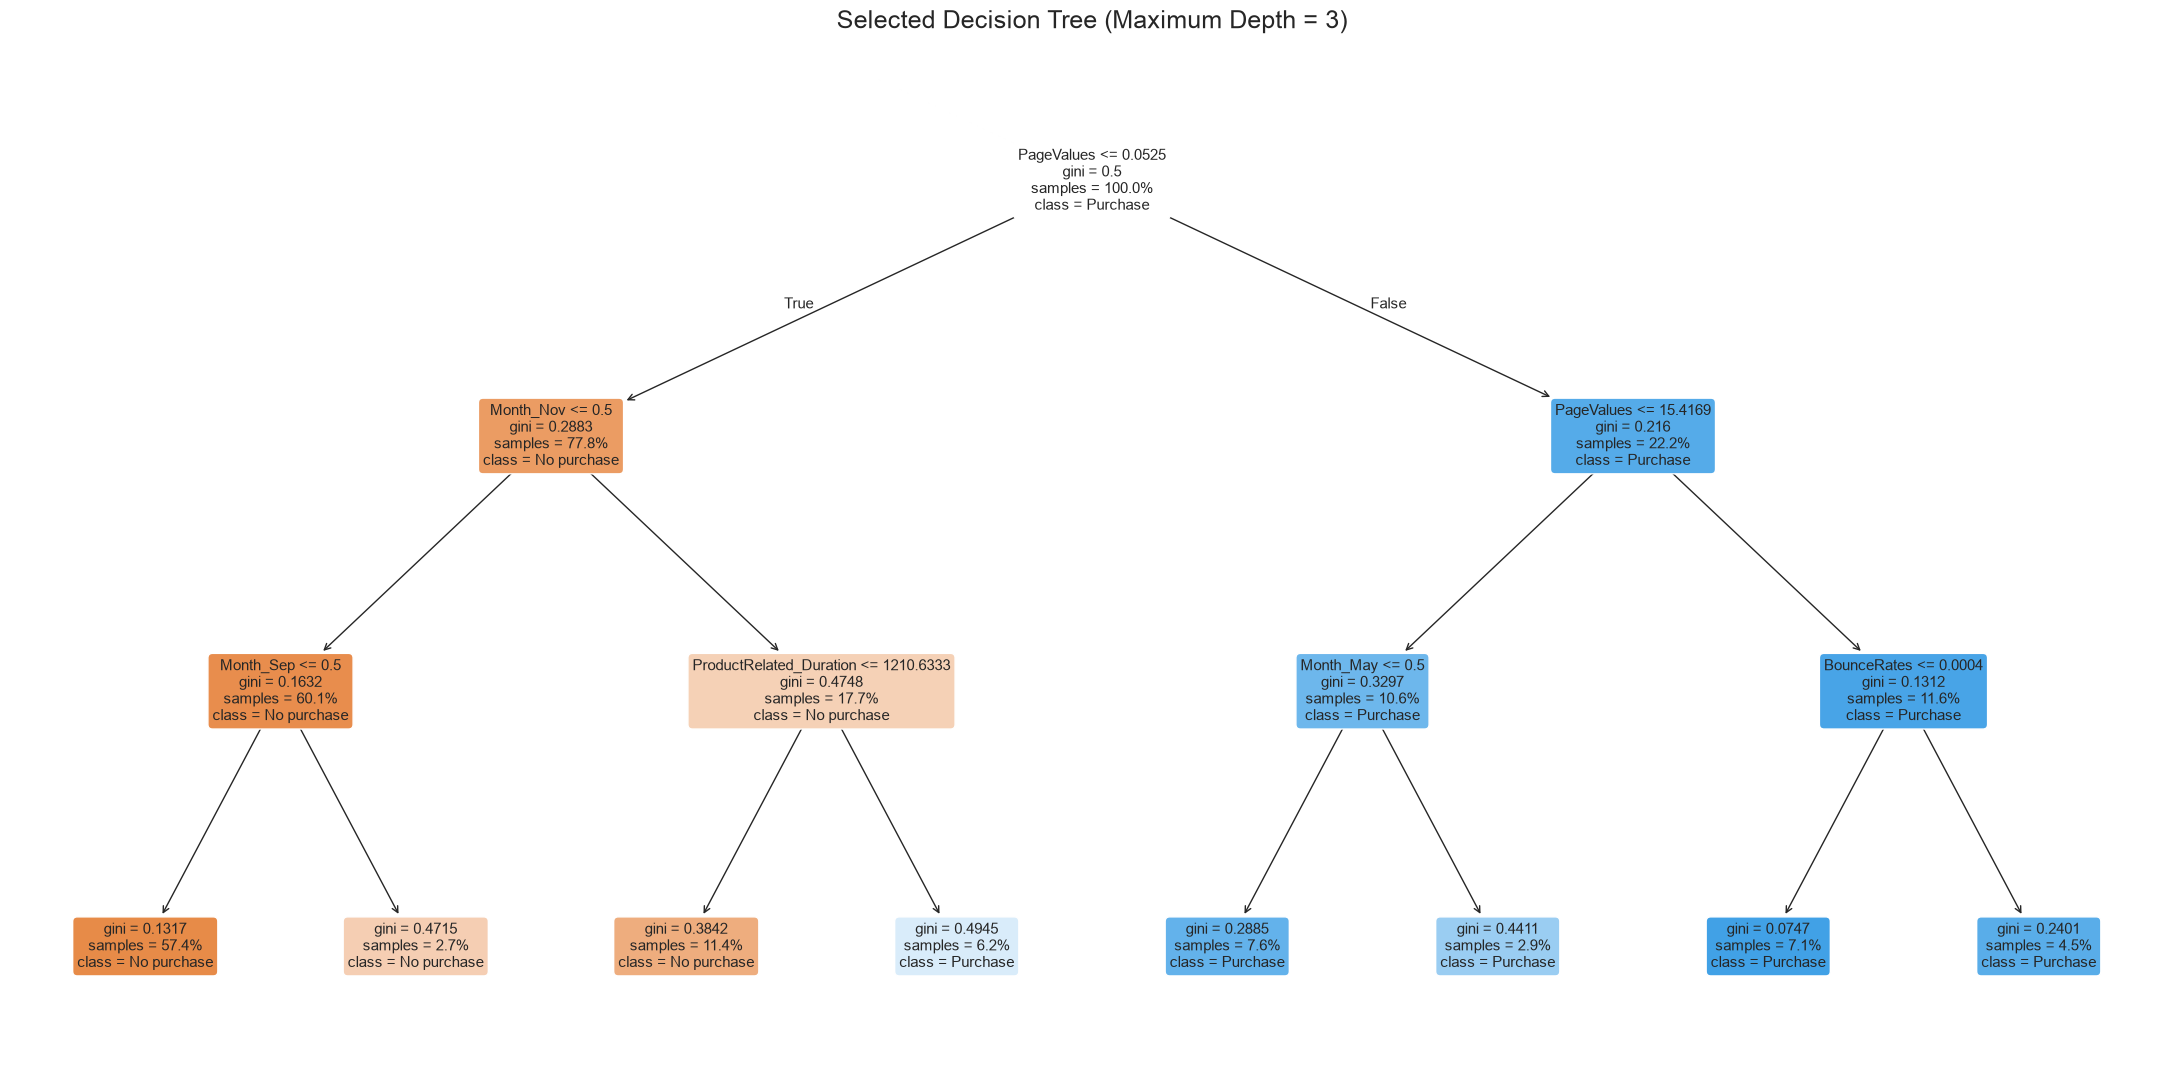

In [41]:
fig, ax = plt.subplots(figsize=(22, 11))

tree_annotations = plot_tree(
    fitted_tree,
    feature_names=transformed_feature_names,
    class_names=["No purchase", "Purchase"],
    filled=True,
    rounded=True,
    proportion=True,
    impurity=True,
    precision=4,
    fontsize=11,
    ax=ax
)

# Remove weighted class proportions from the node labels.
# They can be confusing because the model uses balanced class weights.
for annotation in tree_annotations:
    label_lines = annotation.get_text().split("\n")
    simplified_lines = [
        line for line in label_lines
        if not line.strip().startswith("value")
    ]
    annotation.set_text("\n".join(simplified_lines))

ax.set_title(
    "Selected Decision Tree (Maximum Depth = 3)",
    fontsize=18,
    pad=18
)

plt.tight_layout()

fig.savefig(
    output_path / "selected_decision_tree.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

`PageValues` provides the first division and is used again on the right side of the tree. Sessions with `PageValues` at or below 0.0525 follow the left branch, which is mainly associated with no purchase. For sessions above this initial threshold, a second division occurs at 15.4169, after which the leaves are classified as purchases.

Month indicators, product-related duration and bounce rate refine the classification. Because the months were one-hot encoded, a condition such as `Month_Nov <= 0.5` means that the session did not occur in November. These variables should not be interpreted as isolated causes of purchasing. They identify combinations associated with the outcome in the training data.

The repeated use of `PageValues` shows that the tree depends strongly on this variable. Its position near the top of the model increases predictive usefulness, but it also reinforces the timing concern identified earlier. If `PageValues` would not be available when a decision had to be made, the apparent performance of the model would overstate its operational usefulness. This dependence will be examined through the sensitivity analysis.

## 4.7 Feature Importance

Feature importance measures how much each transformed feature contributed to reducing impurity across the selected tree. A value of zero means that the feature was not used in any split. Importance does not establish causality and may favour variables that offer effective split points in this particular dataset.

In [42]:
# Prepare feature importance results for presentation

feature_label_map = {
    "PageValues": "Page value",
    "Month_Nov": "Month = November",
    "ProductRelated_Duration": "Product-related duration",
    "Month_Sep": "Month = September",
    "Month_May": "Month = May",
    "BounceRates": "Bounce rate"
}

importance_table = used_features.copy()

importance_table["Feature"] = (
    importance_table["Feature"]
    .replace(feature_label_map)
)

importance_table["Importance (%)"] = (
    importance_table["Importance"] * 100
)

importance_table = (
    importance_table
    .drop(columns="Importance")
    .sort_values("Importance (%)", ascending=False)
    .reset_index(drop=True)
)

importance_table.insert(
    0,
    "Rank",
    range(1, len(importance_table) + 1)
)

importance_table.style \
    .hide(axis="index") \
    .format({"Importance (%)": "{:.1f}%"}) \
    .set_caption("Features Used by the Selected Decision Tree") \
    .set_properties(
        subset=["Rank"],
        **{"text-align": "center", "width": "60px"}
    ) \
    .set_properties(
        subset=["Feature"],
        **{"text-align": "left", "min-width": "220px"}
    ) \
    .set_properties(
        subset=["Importance (%)"],
        **{"text-align": "right", "width": "130px"}
    ) \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "15px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        }
    ])

Rank,Feature,Importance (%)
1,Page value,88.4%
2,Month = November,6.9%
3,Product-related duration,2.3%
4,Month = September,1.5%
5,Month = May,0.5%
6,Bounce rate,0.4%


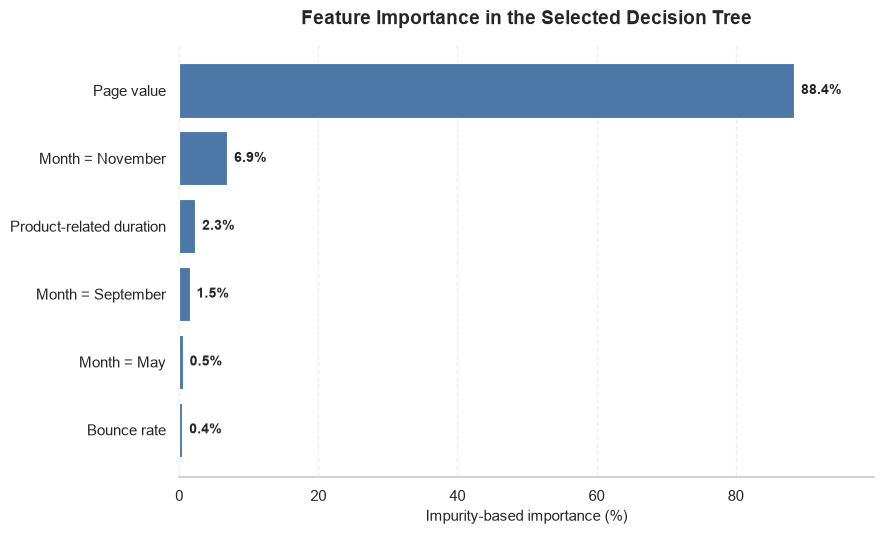

In [43]:
# Plot feature importance using presentation-friendly labels

plot_data = importance_table.sort_values(
    "Importance (%)",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    plot_data["Feature"],
    plot_data["Importance (%)"],
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.8
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in plot_data["Importance (%)"]
    ],
    padding=5,
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Feature Importance in the Selected Decision Tree",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Impurity-based importance (%)", fontsize=11)
ax.set_ylabel("")

ax.set_xlim(
    0,
    plot_data["Importance (%)"].max() * 1.13
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)

sns.despine(ax=ax, left=True, bottom=False)

plt.tight_layout()

fig.savefig(
    output_path / "decision_tree_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Interpretation of Feature Importance

The selected decision tree used only six of the 75 predictors generated during preprocessing. Page value was by far the most influential feature, accounting for 88.4% of the model's total impurity-based importance. This indicates that the tree relied primarily on the estimated commercial value of the pages visited during a session when separating purchase from non-purchase outcomes.

The November indicator contributed 6.9%, while product-related duration represented 2.3%. September, May and bounce rate made smaller contributions. The presence of month indicators suggests that seasonal purchasing patterns influenced some of the model's decisions.

These importance values describe how the selected tree constructed its internal splits. They do not establish causal relationships between the predictors and purchase behaviour. Furthermore, the dominance of page value should be interpreted in relation to prediction timing, since this information may become more informative later in a browsing session. Therefore, a model intended for early intervention may require a separate evaluation using only features available sufficiently early in the customer journey.

## 4.8 Sensitivity Analysis Without PageValues

The selected Decision Tree relies heavily on `PageValues`, which represents 88.4% of its total impurity-based feature importance. The dataset documentation describes this variable as the average value associated with pages visited before an e-commerce transaction. Although it is predictively informative, its availability and reliability may depend on how far the visitor has progressed through the session.

A sensitivity analysis is therefore conducted by removing `PageValues` and repeating the complete model-selection process. The same training and test observations, preprocessing approach, parameter grid, cross-validation procedure and selection metric are retained. This creates a controlled comparison in which the availability of `PageValues` is the only methodological difference.

In [44]:
# Create sensitivity-analysis datasets without PageValues

X_train_without_page_value = X_train.drop(
    columns="PageValues"
)

X_test_without_page_value = X_test.drop(
    columns="PageValues"
)

numerical_features_without_page_value = [
    feature
    for feature in numerical_features
    if feature != "PageValues"
]

sensitivity_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features_without_page_value
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

sensitivity_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            sensitivity_preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

sensitivity_grid_search = GridSearchCV(
    estimator=sensitivity_pipeline,
    param_grid=parameter_grid,
    scoring="balanced_accuracy",
    cv=cross_validation,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

_ = sensitivity_grid_search.fit(
    X_train_without_page_value,
    y_train
)

In [45]:
sensitivity_best_parameters = pd.DataFrame({
    "Parameter": [
        "Predictors excluded",
        "Split criterion",
        "Maximum depth",
        "Minimum samples per leaf",
        "Class weighting",
        "Mean cross-validation balanced accuracy"
    ],
    "Selected value": [
        "PageValues",
        sensitivity_grid_search.best_params_[
            "classifier__criterion"
        ],
        sensitivity_grid_search.best_params_[
            "classifier__max_depth"
        ],
        sensitivity_grid_search.best_params_[
            "classifier__min_samples_leaf"
        ],
        sensitivity_grid_search.best_params_[
            "classifier__class_weight"
        ],
        f"{sensitivity_grid_search.best_score_:.3f}"
    ]
})

sensitivity_best_parameters.style \
    .hide(axis="index") \
    .set_caption(
        "Selected Decision Tree Without PageValues"
    ) \
    .set_properties(
        subset=["Parameter"],
        **{
            "text-align": "left",
            "min-width": "280px"
        }
    ) \
    .set_properties(
        subset=["Selected value"],
        **{
            "text-align": "left",
            "min-width": "150px"
        }
    ) \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "15px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("font-weight", "bold")
            ]
        }
    ])

Parameter,Selected value
Predictors excluded,PageValues
Split criterion,entropy
Maximum depth,None
Minimum samples per leaf,100
Class weighting,balanced
Mean cross-validation balanced accuracy,0.685


In [46]:
sensitivity_model = (
    sensitivity_grid_search.best_estimator_
)

sensitivity_predictions = sensitivity_model.predict(
    X_test_without_page_value
)

sensitivity_scores = [
    accuracy_score(
        y_test,
        sensitivity_predictions
    ),
    balanced_accuracy_score(
        y_test,
        sensitivity_predictions
    ),
    precision_score(
        y_test,
        sensitivity_predictions,
        zero_division=0
    ),
    recall_score(
        y_test,
        sensitivity_predictions,
        zero_division=0
    ),
    f1_score(
        y_test,
        sensitivity_predictions,
        zero_division=0
    )
]

sensitivity_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Precision — Purchase",
        "Recall — Purchase",
        "F1-score — Purchase"
    ],
    "With PageValues (%)": (
        np.array(decision_tree_scores) * 100
    ),
    "Without PageValues (%)": (
        np.array(sensitivity_scores) * 100
    )
})

sensitivity_comparison[
    "Difference (pp)"
] = (
    sensitivity_comparison[
        "Without PageValues (%)"
    ]
    - sensitivity_comparison[
        "With PageValues (%)"
    ]
)

sensitivity_comparison.style \
    .hide(axis="index") \
    .set_caption(
        "Sensitivity Analysis: Effect of Removing PageValues"
    ) \
    .format({
        "With PageValues (%)": "{:.1f}%",
        "Without PageValues (%)": "{:.1f}%",
        "Difference (pp)": "{:+.1f} pp"
    }) \
    .set_properties(
        subset=["Metric"],
        **{
            "text-align": "left",
            "min-width": "190px"
        }
    ) \
    .set_properties(
        subset=[
            "With PageValues (%)",
            "Without PageValues (%)",
            "Difference (pp)"
        ],
        **{
            "text-align": "center",
            "min-width": "140px"
        }
    ) \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "15px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        }
    ])

Metric,With PageValues (%),Without PageValues (%),Difference (pp)
Accuracy,83.3%,63.7%,-19.5 pp
Balanced accuracy,84.3%,66.2%,-18.2 pp
Precision — Purchase,47.7%,25.5%,-22.3 pp
Recall — Purchase,85.9%,69.6%,-16.2 pp
F1-score — Purchase,61.4%,37.3%,-24.1 pp


In [47]:
sensitivity_confusion_matrix = confusion_matrix(
    y_test,
    sensitivity_predictions
)

(
    sensitivity_true_negative,
    sensitivity_false_positive,
    sensitivity_false_negative,
    sensitivity_true_positive
) = sensitivity_confusion_matrix.ravel()

sensitivity_error_comparison = pd.DataFrame({
    "Prediction outcome": [
        "Correctly identified non-purchases",
        "False purchase predictions",
        "Missed purchases",
        "Correctly identified purchases"
    ],
    "With PageValues": [
        true_negative,
        false_positive,
        false_negative,
        true_positive
    ],
    "Without PageValues": [
        sensitivity_true_negative,
        sensitivity_false_positive,
        sensitivity_false_negative,
        sensitivity_true_positive
    ]
})

sensitivity_error_comparison["Difference"] = (
    sensitivity_error_comparison["Without PageValues"]
    - sensitivity_error_comparison["With PageValues"]
)

sensitivity_error_comparison.style \
    .hide(axis="index") \
    .set_caption(
        "Prediction Outcomes With and Without PageValues"
    ) \
    .format({
        "With PageValues": "{:,}",
        "Without PageValues": "{:,}",
        "Difference": "{:+,}"
    }) \
    .set_properties(
        subset=["Prediction outcome"],
        **{
            "text-align": "left",
            "min-width": "270px"
        }
    ) \
    .set_properties(
        subset=[
            "With PageValues",
            "Without PageValues",
            "Difference"
        ],
        **{
            "text-align": "center",
            "min-width": "125px"
        }
    ) \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "15px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        }
    ])

Prediction outcome,With PageValues,Without PageValues,Difference
Correctly identified non-purchases,"1,725","1,306",-419
False purchase predictions,359,778,+419
Missed purchases,54,116,+62
Correctly identified purchases,328,266,-62


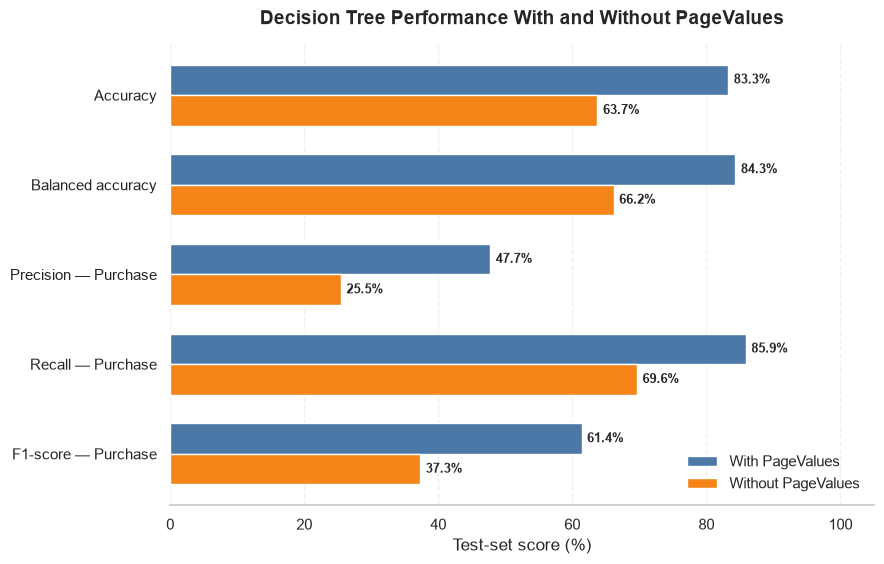

In [48]:
plot_metrics = sensitivity_comparison.copy()

positions = np.arange(len(plot_metrics))
bar_height = 0.34

fig, ax = plt.subplots(figsize=(9, 5.8))

bars_with = ax.barh(
    positions - bar_height / 2,
    plot_metrics["With PageValues (%)"],
    height=bar_height,
    label="With PageValues",
    color="#4C78A8"
)

bars_without = ax.barh(
    positions + bar_height / 2,
    plot_metrics["Without PageValues (%)"],
    height=bar_height,
    label="Without PageValues",
    color="#F58518"
)

ax.bar_label(
    bars_with,
    labels=[
        f"{value:.1f}%"
        for value in plot_metrics[
            "With PageValues (%)"
        ]
    ],
    padding=4,
    fontsize=9,
    fontweight="bold"
)

ax.bar_label(
    bars_without,
    labels=[
        f"{value:.1f}%"
        for value in plot_metrics[
            "Without PageValues (%)"
        ]
    ],
    padding=4,
    fontsize=9,
    fontweight="bold"
)

ax.set_yticks(positions)
ax.set_yticklabels(plot_metrics["Metric"])
ax.invert_yaxis()

ax.set_title(
    "Decision Tree Performance With and Without PageValues",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Test-set score (%)")
ax.set_ylabel("")
ax.set_xlim(0, 105)

ax.legend(
    loc="lower right",
    frameon=False
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)

sns.despine(ax=ax, left=True)

plt.tight_layout()

fig.savefig(
    output_path / "pagevalues_sensitivity_comparison.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Interpretation of the Sensitivity Analysis

Removing `PageValues` produced a substantial decline across all test-set metrics. Balanced accuracy decreased from 84.3% to 66.2%, while the F1-score for purchasing sessions fell from 61.4% to 37.3%. Purchase recall also declined from 85.9% to 69.6%, indicating that the reduced model retained some ability to identify purchasers but missed considerably more of them.

The error comparison provides further context. Without `PageValues`, correctly identified purchases decreased from 328 to 266, while missed purchases increased from 54 to 116. False purchase predictions more than doubled, rising from 359 to 778. Consequently, purchase precision declined from 47.7% to 25.5%. Approximately one in four sessions predicted as a purchase by the reduced model actually resulted in a transaction.

Cross-validation selected an entropy-based tree with no explicit maximum-depth restriction, although the minimum of 100 observations per leaf continued to limit its complexity. Its mean cross-validation balanced accuracy was 68.5%, compared with 66.2% on the test set. The relatively similar results suggest that the lower test performance primarily reflects reduced predictive information rather than an unusually large generalisation gap.

The sensitivity analysis confirms that the main model's performance depends strongly on `PageValues`. Other behavioural and contextual variables still contain useful information, but they cannot reproduce the same level of discrimination. This result does not establish that `PageValues` causes purchases or that it constitutes data leakage. Instead, it highlights an operational dependency: before deployment, the organisation would need to confirm how and when the variable is calculated and whether it is available at the intended intervention point.

## 5. Discussion of Results

The test results demonstrate why accuracy alone is insufficient for evaluating purchase prediction on an imbalanced dataset. The baseline classifier achieved 84.5% accuracy by predicting every session as a non-purchase. However, it failed to identify any of the 382 purchasing sessions, producing zero precision, recall and F1-score for the purchase class.

The selected decision tree achieved a slightly lower accuracy of 83.3%, but its balanced accuracy increased from 50.0% to 84.3%. It correctly identified 328 of the 382 purchasing sessions, corresponding to a recall of 85.9%. The model therefore detected most potential purchasers rather than favouring the majority class.

This improvement involved a trade-off. The model incorrectly classified 359 non-purchasing sessions as purchases, resulting in a purchase precision of 47.7%. In practical terms, approximately 48 of every 100 sessions predicted as purchases were actual purchasing sessions. Whether this performance is valuable depends on the cost and purpose of the business intervention. A low-cost action, such as displaying a personalised recommendation, may tolerate more false positives than an expensive incentive or discount campaign.

The purchase F1-score of 61.4% reflects the compromise between identifying purchasers and limiting false purchase predictions. The balanced accuracy of 84.3% indicates that the model performed similarly across the two outcome classes, correctly recognising 82.8% of non-purchases and 85.9% of purchases.

The selected configuration limited the tree to a maximum depth of three and a minimum of 100 observations per leaf. This produced an interpretable model and limited overfitting, although a shallow tree may not capture more complex interactions in customer behaviour. Cross-validation was used for model and parameter selection, while the test set remained separate until final evaluation.

Feature importance showed that the model relied predominantly on page value. The sensitivity analysis confirmed the practical significance of this dependence: removing `PageValues` reduced balanced accuracy from 84.3% to 66.2% and the purchase F1-score from 61.4% to 37.3%. The reduced model still identified 69.6% of purchasing sessions, showing that the remaining behavioural and contextual predictors retained some useful signal. However, false purchase predictions increased from 359 to 778, reducing purchase precision to 25.5%.

These findings create an operational consideration. `PageValues` substantially improves discrimination, but its usefulness depends on how and when it is calculated. If the objective is to intervene early in the customer journey, the variable must be available before the intended action. Otherwise, the performance of the main model would not represent a realistic early-prediction scenario. The comparison therefore demonstrates a trade-off between predictive performance and the timing of feature availability.

Overall, the decision tree provides a substantial improvement over the majority-class baseline for identifying purchasing sessions. Nevertheless, model performance should be interpreted together with prediction timing, intervention costs and the business consequences of false positives and false negatives.

## 6. Conclusion

This practical example demonstrated the application of a decision tree classifier to predict purchase outcomes from e-commerce session data. The analysis included data understanding, exploratory analysis, preprocessing of numerical and categorical variables, stratified train-test splitting, cross-validated parameter selection and evaluation on a separate test set.

The results confirmed that class imbalance must be considered when evaluating purchase prediction models. Although the majority-class baseline achieved 84.5% accuracy, it was unable to identify any purchasing sessions. The selected decision tree achieved 84.3% balanced accuracy and detected 85.9% of actual purchases, demonstrating substantially greater predictive usefulness despite its slightly lower overall accuracy.

The confusion matrix, tree structure and feature importance analysis supported interpretation of the model. Page value was its dominant predictor, while seasonal indicators, product-related duration and bounce rate made smaller contributions. The sensitivity analysis confirmed this dependence: removing `PageValues` reduced balanced accuracy from 84.3% to 66.2% and the purchase F1-score from 61.4% to 37.3%.

The model could support low-cost actions such as personalised recommendations or service prompts, but deployment decisions should consider prediction timing and the different business costs of false positives and false negatives. In particular, the organisation would need to confirm that `PageValues` is calculated and available before the intended intervention. Further analysis could evaluate alternative classification methods, probability thresholds and predictors available earlier in the browsing session.

Overall, the example shows that an interpretable machine-learning model can convert clickstream-related data into useful purchase predictions when model evaluation is aligned with the characteristics of the data and the intended business decision.

# 7. References

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Sakar, C. O., Polat, S. O., Katircioglu, M., & Kastro, Y. (2019). Real-time prediction of online shoppers’ purchasing intention using multilayer perceptron and LSTM recurrent neural networks. *Neural Computing and Applications, 31*(10), 6893–6908. https://doi.org/10.1007/s00521-018-3523-0

Sakar, C., & Kastro, Y. (2018). *Online Shoppers Purchasing Intention Dataset* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q